In [1]:
from resources.archive.cut_off_black_segments import cut_off_black_segments
import nibabel as nib
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [2]:
PROJECT_DIR = Path(r"C:\Users\abram\PycharmProjects\DrivenData_DAT_Parkinsons")
NIFTI_DIR = PROJECT_DIR / "data" / "niftis"
FILE_NAME = "08liuqdn.nii.gz"
FILE_PATH = NIFTI_DIR / FILE_NAME

In [3]:
original_img = nib.load(FILE_PATH)
original = original_img.get_fdata(dtype=np.float32)

cropped, _ = cut_off_black_segments(
    path=FILE_PATH,
    threshold=0,
    margin=1,
)

In [4]:
filter_width = 3

x_max, y_max, z_max = cropped.shape

filter_3d_x = np.ones((filter_width, y_max, z_max))
filter_sum_3d_x = np.zeros(x_max - filter_width + 1)

for x_pos in range(x_max - filter_width + 1):
    area = cropped[x_pos:x_pos + filter_width, :, :]
    filter_sum_3d_x[x_pos] = np.sum(area * filter_3d_x)

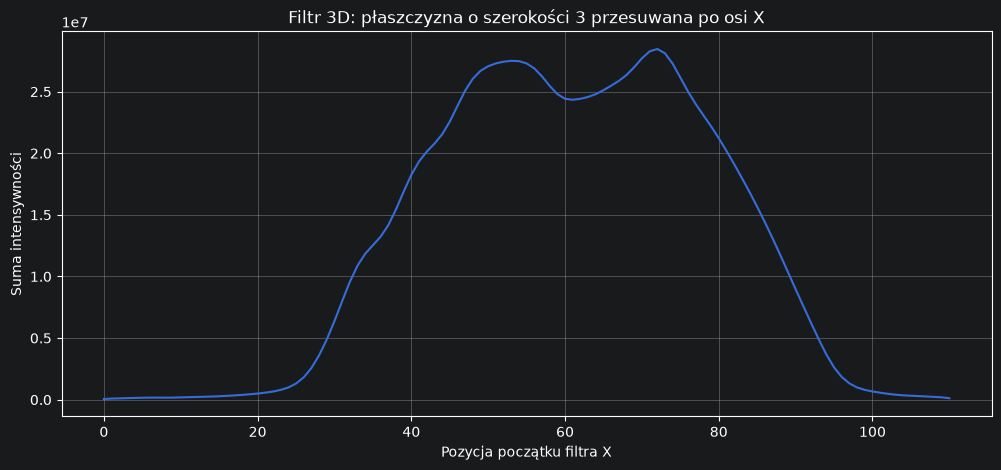

In [5]:
plt.figure(figsize=(12, 5))

plt.plot(np.arange(len(filter_sum_3d_x)), filter_sum_3d_x)
plt.title(f"Filtr 3D: płaszczyzna o szerokości {filter_width} przesuwana po osi X")
plt.xlabel("Pozycja początku filtra X")
plt.ylabel("Suma intensywności")
plt.grid(True)

plt.show()

In [6]:
best_x = np.argmax(filter_sum_3d_x)

print("Największa suma dla x_pos =", best_x)
print("Zakres X:", best_x, "do", best_x + filter_width)
print("Suma:", filter_sum_3d_x[best_x])

Największa suma dla x_pos = 72
Zakres X: 72 do 75
Suma: 28460147.0


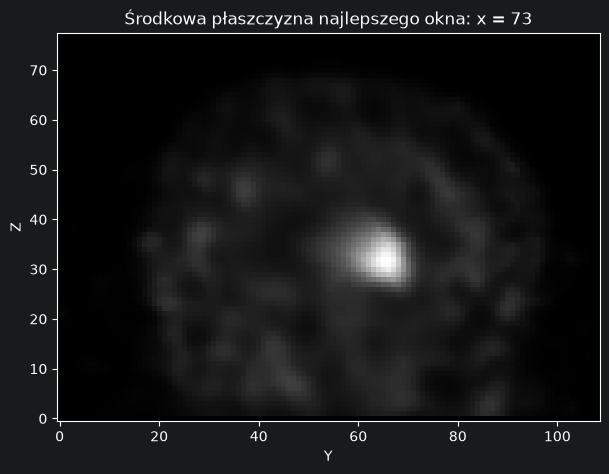

In [7]:
middle_x = best_x + filter_width // 2

plt.figure(figsize=(7, 7))
plt.imshow(cropped[middle_x, :, :].T, cmap="gray", origin="lower")
plt.title(f"Środkowa płaszczyzna najlepszego okna: x = {middle_x}")
plt.xlabel("Y")
plt.ylabel("Z")
plt.show()
